# 02 12.3.E NL IR A61 Cleaning Walkthrough

This notebook walks through the cleaning of ENTSO-E `12.3.E NL IR A61` step by step:

- starting from the raw XML files in `data/00_Raw/ENTSOE/12_3_E/12_3_E_NL_IR_A61`
- transforming the sparse XML payload into a readable points table
- diagnosing duplicates, period boundaries, granularity, gaps, and time coverage
- deriving block intervals from point positions
- expanding those blocks to a canonical quarter-hour UTC grid
- aggregating to conservative hourly outputs

The key structural finding is different from `17.1 B&C`:

- this dataset is **not** one dense row per reported quarter-hour
- the XML uses `curveType = A03`
- points behave like **change points** for variable-duration blocks

So the cleaning rule is: interpret each point as the start of a block that runs until the next point or the end of the Period.


In [1]:
from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path

import pandas as pd
from IPython import get_ipython
from IPython.display import Markdown, display

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 220)
pd.set_option("display.expand_frame_repr", False)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root.")


def load_cleaning_module(repo_root: Path):
    module_path = repo_root / "scripts" / "Data" / "01_cleaning" / "balancing_bid_document_a61_pipeline.py"
    spec = importlib.util.spec_from_file_location("balancing_bid_document_a61_cleaning_notebook", module_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
    return module


REPO_ROOT = find_repo_root()
cleaning = load_cleaning_module(REPO_ROOT)


In [2]:
RAW_DIR = REPO_ROOT / "data" / "00_Raw" / "ENTSOE" / "12_3_E" / "12_3_E_NL_IR_A61"
OUTPUT_DIR = REPO_ROOT / "data" / "01_cleaned" / "Balancing" / "12_3_e_nl_ir_a61"
DIAGNOSTICS_DIR = OUTPUT_DIR / "diagnostics"

config_df = pd.DataFrame(
    [
        {"setting": "Raw input directory", "value": str(RAW_DIR)},
        {"setting": "Cleaned output directory", "value": str(OUTPUT_DIR)},
        {"setting": "Market", "value": cleaning.MARKET},
        {"setting": "Reporting timezone", "value": cleaning.MARKET_TIMEZONE},
        {"setting": "Canonical cleaned resolution", "value": cleaning.CANONICAL_RESOLUTION},
        {"setting": "Known-at rule", "value": cleaning.KNOWN_AT_RULE},
    ]
)
display(config_df)


,setting,value
0,Raw input directory,C:\Users\marijnvalk\PycharmProjects\Thesis\data\00_Raw\ENTSOE\12_3_E\12_3_E_NL_IR_A61
1,Cleaned output directory,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Balancing\12_3_e_nl_ir_a61
2,Market,NL
3,Reporting timezone,Europe/Amsterdam
4,Canonical cleaned resolution,PT15M
5,Known-at rule,not_provided_in_raw_xml


## 1. Raw XML Inventory

Start with the raw files themselves: file sizes, file counts, and the year-style split. This is the quickest way to see whether the export is archived, paginated, or already flattened into plain XML files.


,file,size_kb
0,12_3_e_nl_ir_a61_2024_offset_0000.xml,50.5
1,12_3_e_nl_ir_a61_2025_offset_0000.xml,183.2


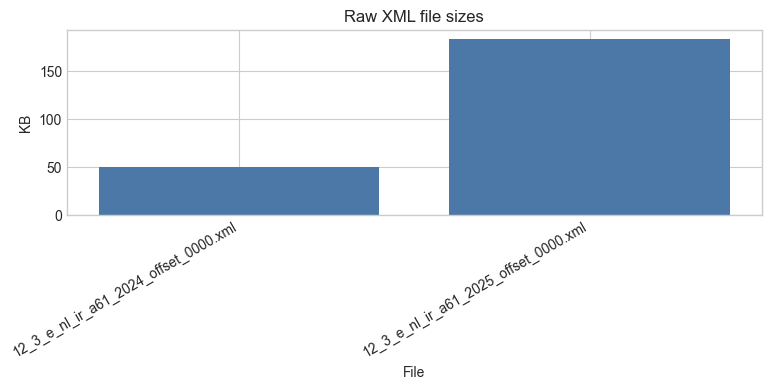

In [3]:
inventory_rows = []
for file_path in sorted(RAW_DIR.glob("*.xml")):
    inventory_rows.append(
        {
            "file": file_path.name,
            "size_kb": round(file_path.stat().st_size / 1024, 1),
        }
    )

inventory_df = pd.DataFrame(inventory_rows)
display(inventory_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(inventory_df["file"], inventory_df["size_kb"], color="#4C78A8")
ax.set_title("Raw XML file sizes")
ax.set_ylabel("KB")
ax.set_xlabel("File")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 2. Inspect One Raw XML Snippet

Before parsing anything, read the first lines of one raw XML file directly. This makes the document structure visible: document type, process type, Period definitions, and Point payload fields.


In [4]:
sample_path = sorted(RAW_DIR.glob("*.xml"))[0]
sample_text = sample_path.read_text(encoding="utf-8", errors="replace")

print("File:", sample_path.name)
print()
print("\n".join(sample_text.splitlines()[:60]))


File: 12_3_e_nl_ir_a61_2024_offset_0000.xml

<?xml version="1.0" encoding="utf-8"?>
<Balancing_MarketDocument xmlns="urn:iec62325.351:tc57wg16:451-6:balancingdocument:4:1">
    <mRID>a02d4e8370244422bcfb6fa855a11550</mRID>
    <revisionNumber>1</revisionNumber>
    <type>A24</type>
    <process.processType>A61</process.processType>
    <sender_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</sender_MarketParticipant.mRID>
    <sender_MarketParticipant.marketRole.type>A32</sender_MarketParticipant.marketRole.type>
    <receiver_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</receiver_MarketParticipant.mRID>
    <receiver_MarketParticipant.marketRole.type>A33</receiver_MarketParticipant.marketRole.type>
    <createdDateTime>2026-03-26T08:51:25Z</createdDateTime>
    <area_Domain.mRID codingScheme="A01">10YNL----------L</area_Domain.mRID>
    <period.timeInterval>
        <start>2024-10-09T10:00Z</start>
        <end>2025-01-01T00:00Z</end>
    </period.timeInterval

## 3. Parse the Raw XML Into a Readable Sparse Points Table

The first real transformation is a readable long table with one row per XML `Point`. At this stage the dataset is still sparse, which is exactly what we want for diagnostics.


In [5]:
points_raw, file_summary_df, parse_errors_df = cleaning.parse_xml_files(RAW_DIR)

print(f"Point rows parsed: {len(points_raw):,}")
print(f"Files parsed: {len(file_summary_df):,}")
print(f"Parse errors: {len(parse_errors_df):,}")

display(file_summary_df)
if not parse_errors_df.empty:
    display(parse_errors_df)


Point rows parsed: 892
Files parsed: 2
Parse errors: 0


,source_file,size_kb,created_datetime_utc,document_type_code,document_type_label,process_type_code,process_type_label,document_period_start_utc,document_period_end_utc,point_rows,period_count,flow_direction_distribution,reported_resolution_distribution
0,12_3_e_nl_ir_a61_2024_offset_0000.xml,50.5,2026-03-26T08:51:25+00:00,A24,Bid_document,A61,Direct_activation_mFRR,2024-10-09T10:00:00+00:00,2025-01-01T00:00:00+00:00,187,4,"{""A01"": 1, ""A02"": 1}","{""PT15M"": 4}"
1,12_3_e_nl_ir_a61_2025_offset_0000.xml,183.2,2026-03-26T08:51:25+00:00,A24,Bid_document,A61,Direct_activation_mFRR,2025-01-01T00:00:00+00:00,2026-01-01T00:00:00+00:00,705,2,"{""A01"": 1, ""A02"": 1}","{""PT15M"": 2}"


In [6]:
readable_points = (
    points_raw[
        [
            "source_file",
            "flow_direction_label",
            "curve_type_label",
            "series_period_start_utc",
            "series_period_end_utc",
            "reported_resolution",
            "point_position",
            "point_timestamp_utc",
            "quantity_maw",
            "secondary_quantity_maw",
            "unavailable_quantity_maw",
        ]
    ]
    .sort_values(["point_timestamp_utc", "flow_direction_label", "point_position"])
    .reset_index(drop=True)
)

display(readable_points.head(20))


,source_file,flow_direction_label,curve_type_label,series_period_start_utc,series_period_end_utc,reported_resolution,point_position,point_timestamp_utc,quantity_maw,secondary_quantity_maw,unavailable_quantity_maw
0,12_3_e_nl_ir_a61_2024_offset_0000.xml,Down,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,1,2024-10-09 10:00:00+00:00,582,0.0,0
1,12_3_e_nl_ir_a61_2024_offset_0000.xml,Up,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,1,2024-10-09 10:00:00+00:00,900,0.0,0
2,12_3_e_nl_ir_a61_2024_offset_0000.xml,Down,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,49,2024-10-09 22:00:00+00:00,670,0.0,0
3,12_3_e_nl_ir_a61_2024_offset_0000.xml,Up,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,49,2024-10-09 22:00:00+00:00,933,0.0,0
4,12_3_e_nl_ir_a61_2024_offset_0000.xml,Down,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,145,2024-10-10 22:00:00+00:00,664,0.0,0
5,12_3_e_nl_ir_a61_2024_offset_0000.xml,Up,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,145,2024-10-10 22:00:00+00:00,902,0.0,0
6,12_3_e_nl_ir_a61_2024_offset_0000.xml,Down,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,241,2024-10-11 22:00:00+00:00,577,0.0,0
7,12_3_e_nl_ir_a61_2024_offset_0000.xml,Up,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,241,2024-10-11 22:00:00+00:00,915,0.0,0
8,12_3_e_nl_ir_a61_2024_offset_0000.xml,Down,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,337,2024-10-12 22:00:00+00:00,639,0.0,0
9,12_3_e_nl_ir_a61_2024_offset_0000.xml,Up,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,337,2024-10-12 22:00:00+00:00,904,0.0,0


## 4. Interpret the Structure

Now answer the structural questions:

- which codes occur
- whether the dataset is truly sparse
- how many points each Period carries versus a dense PT15M grid
- whether there are duplicates to remove


In [7]:
points_long, duplicates_removed = cleaning.deduplicate_points(points_raw)
period_diagnostics = cleaning.build_period_diagnostics(points_long)
points_summary = cleaning.summarize_points(points_long)

overview_df = pd.DataFrame(
    [
        {"metric": "Point rows after deduplication", "value": len(points_long)},
        {"metric": "Duplicates removed", "value": len(duplicates_removed)},
        {"metric": "Min point timestamp UTC", "value": points_long["point_timestamp_utc"].min()},
        {"metric": "Max point timestamp UTC", "value": points_long["point_timestamp_utc"].max()},
        {"metric": "Unique directions", "value": ", ".join(sorted(points_long["flow_direction_label"].dropna().unique()))},
        {"metric": "Unique curve types", "value": ", ".join(sorted(points_long["curve_type_label"].dropna().unique()))},
        {"metric": "Unique resolutions", "value": ", ".join(sorted(points_long["reported_resolution"].dropna().unique()))},
    ]
)
display(overview_df)
display(points_summary)


,metric,value
0,Point rows after deduplication,892
1,Duplicates removed,0
2,Min point timestamp UTC,2024-10-09 10:00:00+00:00
3,Max point timestamp UTC,2025-12-31 23:00:00+00:00
4,Unique directions,"Down, Up"
5,Unique curve types,Variable_block_curve
6,Unique resolutions,PT15M


,flow_direction_code,flow_direction_label,rows,unique_periods,min_point_timestamp_utc,max_point_timestamp_utc,min_local_delivery_date,max_local_delivery_date,reported_resolution_distribution,point_count_distribution
0,A01,Up,475,3,2024-10-09T10:00:00+00:00,2025-12-31T23:00:00+00:00,2024-10-09,2026-01-01,"{""PT15M"": 475}","{""29"": 29, ""361"": 361, ""85"": 85}"
1,A02,Down,417,3,2024-10-09T10:00:00+00:00,2025-12-31T23:00:00+00:00,2024-10-09,2026-01-01,"{""PT15M"": 417}","{""17"": 17, ""344"": 344, ""56"": 56}"


In [8]:
code_tables_df = pd.concat(
    [
        pd.DataFrame(cleaning.DOCUMENT_TYPE_LABELS.items(), columns=["code", "label"]).assign(code_family="document_type"),
        pd.DataFrame(cleaning.PROCESS_TYPE_LABELS.items(), columns=["code", "label"]).assign(code_family="process_type"),
        pd.DataFrame(cleaning.BUSINESS_TYPE_LABELS.items(), columns=["code", "label"]).assign(code_family="business_type"),
        pd.DataFrame(cleaning.CURVE_TYPE_LABELS.items(), columns=["code", "label"]).assign(code_family="curve_type"),
        pd.DataFrame(cleaning.FLOW_DIRECTION_LABELS.items(), columns=["code", "label"]).assign(code_family="flow_direction"),
    ],
    ignore_index=True,
)
display(code_tables_df)


,code,label,code_family
0,A24,Bid_document,document_type
1,A61,Direct_activation_mFRR,process_type
2,A14,Aggregated_energy_data,business_type
3,A01,Sequential_fixed_size_curve,curve_type
4,A02,Point_curve,curve_type
5,A03,Variable_block_curve,curve_type
6,A04,Overlapping_breakpoint_curve,curve_type
7,A05,Non_overlapping_breakpoint_curve,curve_type
8,A01,Up,flow_direction
9,A02,Down,flow_direction


,source_file,timeseries_index,period_index,flow_direction_code,flow_direction_label,business_type_code,business_type_label,market_product_type_code,curve_type_code,curve_type_label,series_period_start_utc,series_period_end_utc,reported_resolution,reported_resolution_minutes,expected_dense_point_count,point_count,first_position,last_position,first_point_timestamp_utc,last_point_timestamp_utc,unique_quantity_levels,period_duration_minutes,compression_ratio_vs_dense_grid
0,12_3_e_nl_ir_a61_2024_offset_0000.xml,2,1,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,15,1690,29,1,1681,2024-10-09 10:00:00+00:00,2024-10-26 22:00:00+00:00,15,25350,0.01716
1,12_3_e_nl_ir_a61_2024_offset_0000.xml,1,1,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,15,1690,17,1,1681,2024-10-09 10:00:00+00:00,2024-10-26 22:00:00+00:00,13,25350,0.010059
2,12_3_e_nl_ir_a61_2024_offset_0000.xml,2,2,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-27 01:00:00+00:00,2025-01-01 00:00:00+00:00,PT15M,15,6332,85,1,6329,2024-10-27 01:00:00+00:00,2024-12-31 23:00:00+00:00,43,94980,0.013424
3,12_3_e_nl_ir_a61_2024_offset_0000.xml,1,2,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-27 01:00:00+00:00,2025-01-01 00:00:00+00:00,PT15M,15,6332,56,1,6329,2024-10-27 01:00:00+00:00,2024-12-31 23:00:00+00:00,39,94980,0.008844
4,12_3_e_nl_ir_a61_2025_offset_0000.xml,2,1,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2025-01-01 00:00:00+00:00,2026-01-01 00:00:00+00:00,PT15M,15,35040,361,1,35037,2025-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,157,525600,0.010303
5,12_3_e_nl_ir_a61_2025_offset_0000.xml,1,1,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2025-01-01 00:00:00+00:00,2026-01-01 00:00:00+00:00,PT15M,15,35040,344,1,35037,2025-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,140,525600,0.009817


,family,market,source_file,created_datetime_utc,document_type_code,document_type_label,process_type_code,process_type_label,area_domain,document_period_start_utc,document_period_end_utc,timeseries_index,period_index,business_type_code,business_type_label,market_product_type_code,flow_direction_code,flow_direction_label,curve_type_code,curve_type_label,quantity_unit,series_period_start_utc,series_period_end_utc,reported_resolution,reported_resolution_minutes,point_count_in_period,expected_dense_point_count,point_position,point_timestamp_utc,quantity_maw,secondary_quantity_maw,unavailable_quantity_maw


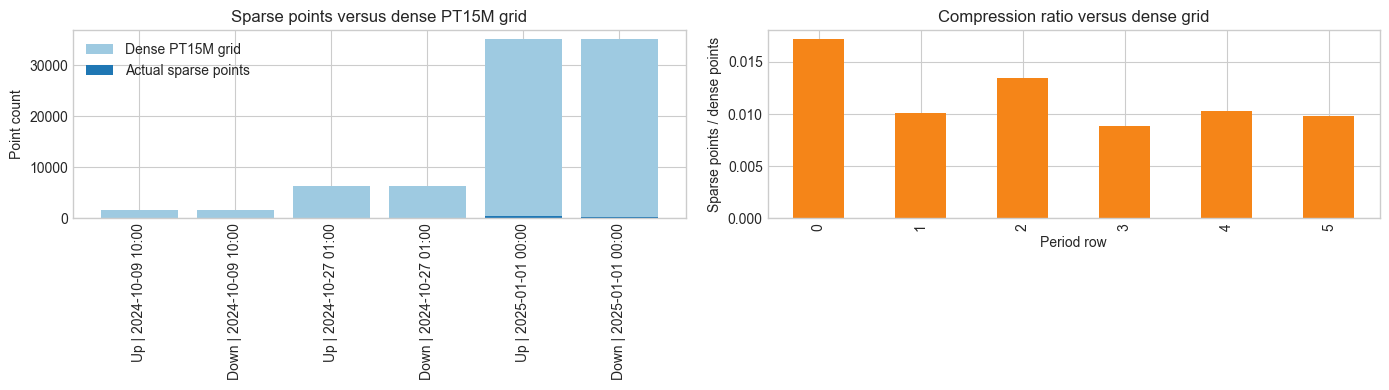

In [9]:
display(period_diagnostics)
display(duplicates_removed.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dense_compare = period_diagnostics.copy()
dense_compare["period_label"] = (
    dense_compare["flow_direction_label"]
    + " | "
    + dense_compare["series_period_start_utc"].dt.strftime("%Y-%m-%d %H:%M")
)
axes[0].bar(dense_compare["period_label"], dense_compare["expected_dense_point_count"], color="#9ECAE1", label="Dense PT15M grid")
axes[0].bar(dense_compare["period_label"], dense_compare["point_count"], color="#1F77B4", label="Actual sparse points")
axes[0].set_title("Sparse points versus dense PT15M grid")
axes[0].set_ylabel("Point count")
axes[0].tick_params(axis="x", rotation=90)
axes[0].legend()

period_diagnostics["compression_ratio_vs_dense_grid"].plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Compression ratio versus dense grid")
axes[1].set_xlabel("Period row")
axes[1].set_ylabel("Sparse points / dense points")

plt.tight_layout()
plt.show()


## 5. Cleaning Step 1: Convert Sparse Points Into Blocks

This is the central cleaning step. For `curveType = A03`, each point is treated as a block start:

- `block_start_utc = point_timestamp_utc`
- `block_end_utc = next point timestamp`
- if there is no next point, the block ends at the Period end


In [10]:
blocks_long = cleaning.build_blocks(points_long)
blocks_summary = cleaning.summarize_blocks(blocks_long)

display(blocks_long.head(20))
display(blocks_summary)


,block_id,family,market,source_file,created_datetime_utc,document_type_code,document_type_label,process_type_code,process_type_label,area_domain,timeseries_index,period_index,business_type_code,business_type_label,market_product_type_code,flow_direction_code,flow_direction_label,curve_type_code,curve_type_label,quantity_unit,series_period_start_utc,series_period_end_utc,reported_resolution,reported_resolution_minutes,point_count_in_period,expected_dense_point_count,point_position,native_point_timestamp_utc,next_point_position,next_point_timestamp_utc,block_start_utc,block_end_utc,block_duration_minutes,block_quarterhour_count,block_position_step,block_interpretation,quantity_maw,secondary_quantity_maw,unavailable_quantity_maw
0,74,12_3_e_nl_ir_a61,NL,12_3_e_nl_ir_a61_2024_offset_0000.xml,2026-03-26 08:51:25+00:00,A24,Bid_document,A61,Direct_activation_mFRR,10YNL----------L,2,1,A14,Aggregated_energy_data,A02,A01,Up,A03,Variable_block_curve,MAW,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,15,29,1690,1,2024-10-09 10:00:00+00:00,49,2024-10-09 22:00:00+00:00,2024-10-09 10:00:00+00:00,2024-10-09 22:00:00+00:00,720,48,48,change_point_to_next_position,900,0.0,0
1,1,12_3_e_nl_ir_a61,NL,12_3_e_nl_ir_a61_2024_offset_0000.xml,2026-03-26 08:51:25+00:00,A24,Bid_document,A61,Direct_activation_mFRR,10YNL----------L,1,1,A14,Aggregated_energy_data,A02,A02,Down,A03,Variable_block_curve,MAW,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,15,17,1690,1,2024-10-09 10:00:00+00:00,49,2024-10-09 22:00:00+00:00,2024-10-09 10:00:00+00:00,2024-10-09 22:00:00+00:00,720,48,48,change_point_to_next_position,582,0.0,0
2,75,12_3_e_nl_ir_a61,NL,12_3_e_nl_ir_a61_2024_offset_0000.xml,2026-03-26 08:51:25+00:00,A24,Bid_document,A61,Direct_activation_mFRR,10YNL----------L,2,1,A14,Aggregated_energy_data,A02,A01,Up,A03,Variable_block_curve,MAW,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,15,29,1690,49,2024-10-09 22:00:00+00:00,145,2024-10-10 22:00:00+00:00,2024-10-09 22:00:00+00:00,2024-10-10 22:00:00+00:00,1440,96,96,change_point_to_next_position,933,0.0,0
3,2,12_3_e_nl_ir_a61,NL,12_3_e_nl_ir_a61_2024_offset_0000.xml,2026-03-26 08:51:25+00:00,A24,Bid_document,A61,Direct_activation_mFRR,10YNL----------L,1,1,A14,Aggregated_energy_data,A02,A02,Down,A03,Variable_block_curve,MAW,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,15,17,1690,49,2024-10-09 22:00:00+00:00,145,2024-10-10 22:00:00+00:00,2024-10-09 22:00:00+00:00,2024-10-10 22:00:00+00:00,1440,96,96,change_point_to_next_position,670,0.0,0
4,76,12_3_e_nl_ir_a61,NL,12_3_e_nl_ir_a61_2024_offset_0000.xml,2026-03-26 08:51:25+00:00,A24,Bid_document,A61,Direct_activation_mFRR,10YNL----------L,2,1,A14,Aggregated_energy_data,A02,A01,Up,A03,Variable_block_curve,MAW,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,15,29,1690,145,2024-10-10 22:00:00+00:00,241,2024-10-11 22:00:00+00:00,2024-10-10 22:00:00+00:00,2024-10-11 22:00:00+00:00,1440,96,96,change_point_to_next_position,902,0.0,0
5,3,12_3_e_nl_ir_a61,NL,12_3_e_nl_ir_a61_2024_offset_0000.xml,2026-03-26 08:51:25+00:00,A24,Bid_document,A61,Direct_activation_mFRR,10YNL----------L,1,1,A14,Aggregated_energy_data,A02,A02,Down,A03,Variable_block_curve,MAW,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,15,17,1690,145,2024-10-10 22:00:00+00:00,241,2024-10-11 22:00:00+00:00,2024-10-10 22:00:00+00:00,2024-10-11 22:00:00+00:00,1440,96,96,change_point_to_next_position,664,0.0,0
6,77,12_3_e_nl_ir_a61,NL,12_3_e_nl_ir_a61_2024_offset_0000.xml,2026-03-26 08:51:25+00:00,A24,Bid_document,A61,Direct_activation_mFRR,10YNL----------L,2,1,A14,Aggregated_energy_data,A02,A01,Up,A03,Variable_block_curve,MAW,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,PT15M,15,29,1690,241,2024-10-11 22:00:00+00:00,337,2024-10-12 22:00:00+00:00,2024-10-11 22:00:00+00:00,2024-10-12 22:00:00+00:00,1440,96,96,change_point_to_next_position,915,0.0,0
7,4,12_3_e_nl_ir_a61,NL,12_3_e_nl_ir_a61_2024_offset_0000.xml,2026-03-26 08:51:25+00:00,A24,Bid_docu

,flow_direction_code,flow_direction_label,rows,min_block_start_utc,max_block_end_utc,min_block_duration_minutes,max_block_duration_minutes,block_duration_distribution
0,A01,Up,475,2024-10-09T10:00:00+00:00,2026-01-01T00:00:00+00:00,15,12135,"{""1035"": 1, ""1080"": 1, ""1125"": 1, ""120"": 1, ""12135"": 1, ""1215"": 1, ""1245"": 3, ""1320"": 1, ""1335"": 1, ""135"": 1, ""1380"": 2, ""1440"": 334, ""15"": 55, ""150"": 2, ""1500"": 1, ""1620"": 1, ""165"": 1, ""180"": 1, ""210"": 1, ""2115"": 1, ""2160"": 1, ""2175"": 1, ""255"": 1, ""270"": 1, ""2715"": 1, ""285"": 1, ""2880"": 18, ""30"": 7, ""300"": 1, ""4320"": 8, ""45"": 5, ""555"": 1, ""5760"": 4, ""585"": 1, ""60"": 3, ""600"": 2, ""6405"": 1, ""660"": 2, ""705"": 1, ""720"": 1, ""735"": 1, ""765"": 1, ""855"": 1}"
1,A02,Down,417,2024-10-09T10:00:00+00:00,2026-01-01T00:00:00+00:00,15,12960,"{""12960"": 1, ""1320"": 1, ""1380"": 2, ""1440"": 365, ""15"": 12, ""150"": 1, ""1500"": 1, ""1905"": 1, ""2880"": 13, ""4320"": 5, ""525"": 1, ""5760"": 5, ""585"": 1, ""60"": 2, ""720"": 1, ""7200"": 1, ""75"": 1, ""780"": 1, ""795"": 1, ""915"": 1}"


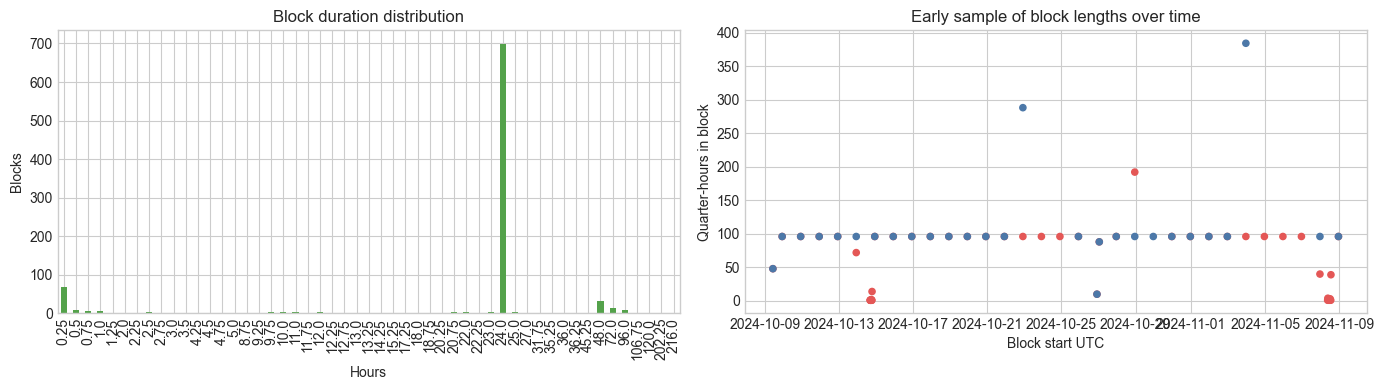

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

block_duration_hours = blocks_long["block_duration_minutes"] / 60.0
block_duration_hours.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#54A24B")
axes[0].set_title("Block duration distribution")
axes[0].set_xlabel("Hours")
axes[0].set_ylabel("Blocks")

sample_blocks = blocks_long.head(80).copy()
axes[1].scatter(
    sample_blocks["native_point_timestamp_utc"],
    sample_blocks["block_quarterhour_count"],
    c=sample_blocks["flow_direction_code"].map({"A01": "#E45756", "A02": "#4C78A8"}),
    s=20,
)
axes[1].set_title("Early sample of block lengths over time")
axes[1].set_ylabel("Quarter-hours in block")
axes[1].set_xlabel("Block start UTC")

plt.tight_layout()
plt.show()


## 6. Cleaning Step 2: Expand Blocks to a Canonical Quarter-Hour UTC Grid

Once blocks are explicit, expand them to one row per actual quarter-hour covered by the block. This creates the canonical cleaned grid used for diagnostics, visualization, and later hourly aggregation.


In [12]:
quarterhour_long = cleaning.expand_blocks_to_quarterhour(blocks_long)
quarterhour_wide = cleaning.build_quarterhour_wide(quarterhour_long)
quarterhour_summary = cleaning.summarize_quarterhour(quarterhour_long)
gap_intervals, gap_summary = cleaning.find_gap_intervals(quarterhour_long)

print(f"Quarter-hour rows: {len(quarterhour_long):,}")
display(quarterhour_summary)
display(quarterhour_long.head(20))
display(quarterhour_wide.head(12))


Quarter-hour rows: 86,124


,flow_direction_code,flow_direction_label,rows,unique_intervals,min_timestamp_utc,max_interval_end_utc,min_local_delivery_date,max_local_delivery_date
0,A01,Up,43062,43062,2024-10-09T10:00:00+00:00,2026-01-01T00:00:00+00:00,2024-10-09,2026-01-01
1,A02,Down,43062,43062,2024-10-09T10:00:00+00:00,2026-01-01T00:00:00+00:00,2024-10-09,2026-01-01


,family,market,timestamp_utc,interval_end_utc,resolution_minutes,quantity_maw,secondary_quantity_maw,unavailable_quantity_maw,source_block_id,source_file,flow_direction_code,flow_direction_label,business_type_code,business_type_label,market_product_type_code,curve_type_code,curve_type_label,series_period_start_utc,series_period_end_utc,block_start_utc,block_end_utc,block_duration_minutes,target_delivery_local_date,target_hour_local,target_minute_local
0,12_3_e_nl_ir_a61,NL,2024-10-09 10:00:00+00:00,2024-10-09 10:15:00+00:00,15,900,0.0,0,74,12_3_e_nl_ir_a61_2024_offset_0000.xml,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,2024-10-09 10:00:00+00:00,2024-10-09 22:00:00+00:00,720,2024-10-09,12,0
1,12_3_e_nl_ir_a61,NL,2024-10-09 10:00:00+00:00,2024-10-09 10:15:00+00:00,15,582,0.0,0,1,12_3_e_nl_ir_a61_2024_offset_0000.xml,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,2024-10-09 10:00:00+00:00,2024-10-09 22:00:00+00:00,720,2024-10-09,12,0
2,12_3_e_nl_ir_a61,NL,2024-10-09 10:15:00+00:00,2024-10-09 10:30:00+00:00,15,900,0.0,0,74,12_3_e_nl_ir_a61_2024_offset_0000.xml,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,2024-10-09 10:00:00+00:00,2024-10-09 22:00:00+00:00,720,2024-10-09,12,15
3,12_3_e_nl_ir_a61,NL,2024-10-09 10:15:00+00:00,2024-10-09 10:30:00+00:00,15,582,0.0,0,1,12_3_e_nl_ir_a61_2024_offset_0000.xml,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,2024-10-09 10:00:00+00:00,2024-10-09 22:00:00+00:00,720,2024-10-09,12,15
4,12_3_e_nl_ir_a61,NL,2024-10-09 10:30:00+00:00,2024-10-09 10:45:00+00:00,15,900,0.0,0,74,12_3_e_nl_ir_a61_2024_offset_0000.xml,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,2024-10-09 10:00:00+00:00,2024-10-09 22:00:00+00:00,720,2024-10-09,12,30
5,12_3_e_nl_ir_a61,NL,2024-10-09 10:30:00+00:00,2024-10-09 10:45:00+00:00,15,582,0.0,0,1,12_3_e_nl_ir_a61_2024_offset_0000.xml,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,2024-10-09 10:00:00+00:00,2024-10-09 22:00:00+00:00,720,2024-10-09,12,30
6,12_3_e_nl_ir_a61,NL,2024-10-09 10:45:00+00:00,2024-10-09 11:00:00+00:00,15,900,0.0,0,74,12_3_e_nl_ir_a61_2024_offset_0000.xml,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,2024-10-09 10:00:00+00:00,2024-10-09 22:00:00+00:00,720,2024-10-09,12,45
7,12_3_e_nl_ir_a61,NL,2024-10-09 10:45:00+00:00,2024-10-09 11:00:00+00:00,15,582,0.0,0,1,12_3_e_nl_ir_a61_2024_offset_0000.xml,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,2024-10-09 10:00:00+00:00,2024-10-09 22:00:00+00:00,720,2024-10-09,12,45
8,12_3_e_nl_ir_a61,NL,2024-10-09 11:00:00+00:00,2024-10-09 11:15:00+00:00,15,900,0.0,0,74,12_3_e_nl_ir_a61_2024_offset_0000.xml,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,2024-10-09 10:00:00+00:00,2024-10-09 22:00:00+00:00,720,2024-10-09,13,0
9,12_3_e_nl_ir_a61,NL,2024-10-09 11:00:00+00:00,2024-10-09 11:15:00+00:00,15,582,0.0,0,1,12_3_e_nl_ir_a61_2024_offset_0000.xml,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09 10:00:00+00:00,2024-10-27 00:30:00+00:00,2024-10-09 10:00:00+00:00,2024-10-09 22:00:00+00:00,720,2024-10-09,13,0


,timestamp_utc,nl_down_quantity_maw,nl_down_secondary_quantity_maw,nl_down_unavailable_quantity_maw,nl_up_quantity_maw,nl_up_secondary_quantity_maw,nl_up_unavailable_quantity_maw
0,2024-10-09 10:00:00+00:00,582,0.0,0,900,0.0,0
1,2024-10-09 10:15:00+00:00,582,0.0,0,900,0.0,0
2,2024-10-09 10:30:00+00:00,582,0.0,0,900,0.0,0
3,2024-10-09 10:45:00+00:00,582,0.0,0,900,0.0,0
4,2024-10-09 11:00:00+00:00,582,0.0,0,900,0.0,0
5,2024-10-09 11:15:00+00:00,582,0.0,0,900,0.0,0
6,2024-10-09 11:30:00+00:00,582,0.0,0,900,0.0,0
7,2024-10-09 11:45:00+00:00,582,0.0,0,900,0.0,0
8,2024-10-09 12:00:00+00:00,582,0.0,0,900,0.0,0
9,2024-10-09 12:15:00+00:00,582,0.0,0,900,0.0,0


,market,flow_direction_code,flow_direction_label,timestamp_utc,interval_end_utc
0,NL,A01,Up,2024-10-27 00:30:00+00:00,2024-10-27 00:45:00+00:00
1,NL,A01,Up,2024-10-27 00:45:00+00:00,2024-10-27 01:00:00+00:00
2,NL,A02,Down,2024-10-27 00:30:00+00:00,2024-10-27 00:45:00+00:00
3,NL,A02,Down,2024-10-27 00:45:00+00:00,2024-10-27 01:00:00+00:00


,gap_start_utc,missing_quarterhours,gap_end_utc,market,flow_direction_code,flow_direction_label,merged_gap_count
0,2024-10-27 00:30:00+00:00,2,2024-10-27 01:00:00+00:00,NL,A01,Up,1
1,2024-10-27 00:30:00+00:00,2,2024-10-27 01:00:00+00:00,NL,A02,Down,1


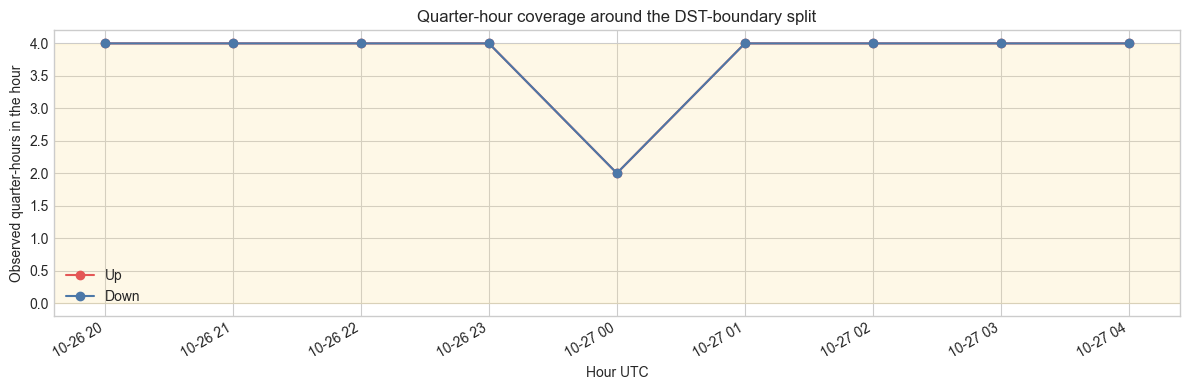

In [13]:
display(gap_intervals.head(20))
display(gap_summary)

coverage_window = (
    quarterhour_long.assign(hour_timestamp_utc=quarterhour_long["timestamp_utc"].dt.floor("h"))
    .groupby(["hour_timestamp_utc", "flow_direction_label"], as_index=False)
    .agg(quarterhours=("timestamp_utc", "size"))
)
coverage_window = coverage_window[
    (coverage_window["hour_timestamp_utc"] >= pd.Timestamp("2024-10-26 20:00:00+00:00"))
    & (coverage_window["hour_timestamp_utc"] <= pd.Timestamp("2024-10-27 04:00:00+00:00"))
]

fig, ax = plt.subplots(figsize=(12, 4))
for label, color in [("Up", "#E45756"), ("Down", "#4C78A8")]:
    subset = coverage_window[coverage_window["flow_direction_label"] == label]
    ax.plot(subset["hour_timestamp_utc"], subset["quarterhours"], marker="o", label=label, color=color)
ax.axhspan(0, 3.99, color="#FEE08B", alpha=0.2)
ax.set_title("Quarter-hour coverage around the DST-boundary split")
ax.set_ylabel("Observed quarter-hours in the hour")
ax.set_xlabel("Hour UTC")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


C:\Users\marijnvalk\AppData\Local\Temp\ipykernel_27912\1281468233.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  quarterhour_long.assign(month=quarterhour_long["timestamp_utc"].dt.to_period("M").astype(str))


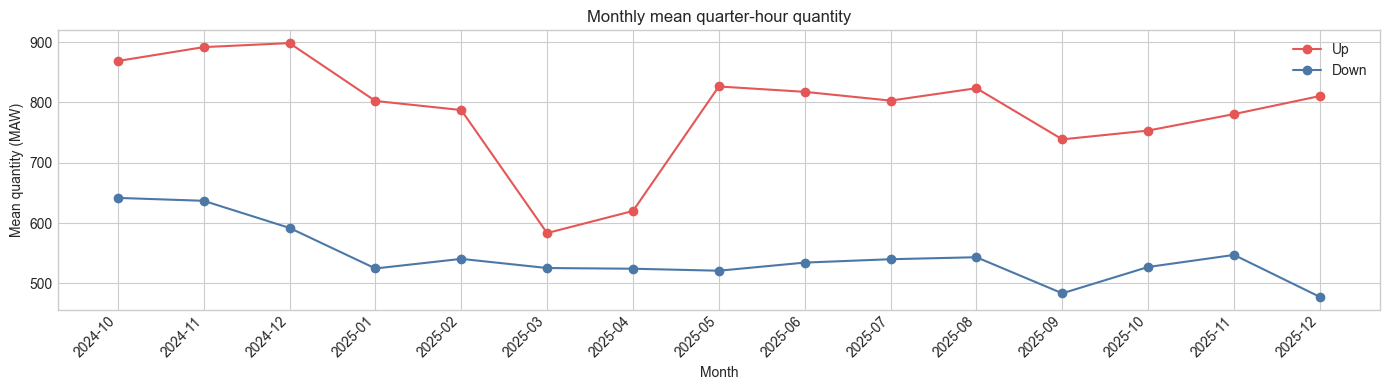

In [14]:
monthly_quantity = (
    quarterhour_long.assign(month=quarterhour_long["timestamp_utc"].dt.to_period("M").astype(str))
    .groupby(["month", "flow_direction_label"], as_index=False)
    .agg(mean_quantity_maw=("quantity_maw", "mean"))
)

fig, ax = plt.subplots(figsize=(14, 4))
for label, color in [("Up", "#E45756"), ("Down", "#4C78A8")]:
    subset = monthly_quantity[monthly_quantity["flow_direction_label"] == label]
    ax.plot(subset["month"], subset["mean_quantity_maw"], marker="o", label=label, color=color)
ax.set_title("Monthly mean quarter-hour quantity")
ax.set_ylabel("Mean quantity (MAW)")
ax.set_xlabel("Month")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 7. Cleaning Step 3: Aggregate to Conservative Hourly Outputs

Hourly aggregation is done from the cleaned quarter-hour table:

- average across quarter-hours inside the hour
- keep coverage diagnostics
- set value columns to missing when the hour is incomplete


In [15]:
hourly_long = cleaning.aggregate_hourly(quarterhour_long)
hourly_wide = cleaning.build_hourly_wide(hourly_long)
hourly_summary = cleaning.summarize_hourly(hourly_long)

print(f"Hourly rows: {len(hourly_long):,}")
display(hourly_summary)
display(hourly_long.head(20))
display(hourly_wide.head(12))


Hourly rows: 21,532


,flow_direction_code,flow_direction_label,rows,unique_hours,incomplete_hours,min_timestamp_utc,max_interval_end_utc,min_local_delivery_date,max_local_delivery_date
0,A01,Up,10766,10766,1,2024-10-09T10:00:00+00:00,2026-01-01T00:00:00+00:00,2024-10-09,2026-01-01
1,A02,Down,10766,10766,1,2024-10-09T10:00:00+00:00,2026-01-01T00:00:00+00:00,2024-10-09,2026-01-01


,family,market,timestamp_utc,interval_end_utc,quantity_maw,secondary_quantity_maw,unavailable_quantity_maw,quarterhour_count,coverage_minutes,expected_coverage_minutes,is_complete_hour,source_block_count,source_file_count,flow_direction_code,flow_direction_label,business_type_code,business_type_label,market_product_type_code,curve_type_code,curve_type_label,target_delivery_local_date,target_hour_local,target_minute_local,known_at_utc,known_at_rule
0,12_3_e_nl_ir_a61,NL,2024-10-09 10:00:00+00:00,2024-10-09 11:00:00+00:00,900.0,0.0,0.0,4,60,60,True,1,1,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09,12,0,NaT,not_provided_in_raw_xml
1,12_3_e_nl_ir_a61,NL,2024-10-09 10:00:00+00:00,2024-10-09 11:00:00+00:00,582.0,0.0,0.0,4,60,60,True,1,1,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09,12,0,NaT,not_provided_in_raw_xml
2,12_3_e_nl_ir_a61,NL,2024-10-09 11:00:00+00:00,2024-10-09 12:00:00+00:00,900.0,0.0,0.0,4,60,60,True,1,1,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09,13,0,NaT,not_provided_in_raw_xml
3,12_3_e_nl_ir_a61,NL,2024-10-09 11:00:00+00:00,2024-10-09 12:00:00+00:00,582.0,0.0,0.0,4,60,60,True,1,1,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09,13,0,NaT,not_provided_in_raw_xml
4,12_3_e_nl_ir_a61,NL,2024-10-09 12:00:00+00:00,2024-10-09 13:00:00+00:00,900.0,0.0,0.0,4,60,60,True,1,1,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09,14,0,NaT,not_provided_in_raw_xml
5,12_3_e_nl_ir_a61,NL,2024-10-09 12:00:00+00:00,2024-10-09 13:00:00+00:00,582.0,0.0,0.0,4,60,60,True,1,1,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09,14,0,NaT,not_provided_in_raw_xml
6,12_3_e_nl_ir_a61,NL,2024-10-09 13:00:00+00:00,2024-10-09 14:00:00+00:00,900.0,0.0,0.0,4,60,60,True,1,1,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09,15,0,NaT,not_provided_in_raw_xml
7,12_3_e_nl_ir_a61,NL,2024-10-09 13:00:00+00:00,2024-10-09 14:00:00+00:00,582.0,0.0,0.0,4,60,60,True,1,1,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09,15,0,NaT,not_provided_in_raw_xml
8,12_3_e_nl_ir_a61,NL,2024-10-09 14:00:00+00:00,2024-10-09 15:00:00+00:00,900.0,0.0,0.0,4,60,60,True,1,1,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09,16,0,NaT,not_provided_in_raw_xml
9,12_3_e_nl_ir_a61,NL,2024-10-09 14:00:00+00:00,2024-10-09 15:00:00+00:00,582.0,0.0,0.0,4,60,60,True,1,1,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-09,16,0,NaT,not_provided_in_raw_xml


,timestamp_utc,nl_down_quantity_maw,nl_down_secondary_quantity_maw,nl_down_unavailable_quantity_maw,nl_up_quantity_maw,nl_up_secondary_quantity_maw,nl_up_unavailable_quantity_maw
0,2024-10-09 10:00:00+00:00,582.0,0.0,0.0,900.0,0.0,0.0
1,2024-10-09 11:00:00+00:00,582.0,0.0,0.0,900.0,0.0,0.0
2,2024-10-09 12:00:00+00:00,582.0,0.0,0.0,900.0,0.0,0.0
3,2024-10-09 13:00:00+00:00,582.0,0.0,0.0,900.0,0.0,0.0
4,2024-10-09 14:00:00+00:00,582.0,0.0,0.0,900.0,0.0,0.0
5,2024-10-09 15:00:00+00:00,582.0,0.0,0.0,900.0,0.0,0.0
6,2024-10-09 16:00:00+00:00,582.0,0.0,0.0,900.0,0.0,0.0
7,2024-10-09 17:00:00+00:00,582.0,0.0,0.0,900.0,0.0,0.0
8,2024-10-09 18:00:00+00:00,582.0,0.0,0.0,900.0,0.0,0.0
9,2024-10-09 19:00:00+00:00,582.0,0.0,0.0,900.0,0.0,0.0


,family,market,timestamp_utc,interval_end_utc,quantity_maw,secondary_quantity_maw,unavailable_quantity_maw,quarterhour_count,coverage_minutes,expected_coverage_minutes,is_complete_hour,source_block_count,source_file_count,flow_direction_code,flow_direction_label,business_type_code,business_type_label,market_product_type_code,curve_type_code,curve_type_label,target_delivery_local_date,target_hour_local,target_minute_local,known_at_utc,known_at_rule
844,12_3_e_nl_ir_a61,NL,2024-10-27 00:00:00+00:00,2024-10-27 01:00:00+00:00,NaN,NaN,NaN,2,30,60,False,1,1,A01,Up,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-27,2,0,NaT,not_provided_in_raw_xml
845,12_3_e_nl_ir_a61,NL,2024-10-27 00:00:00+00:00,2024-10-27 01:00:00+00:00,NaN,NaN,NaN,2,30,60,False,1,1,A02,Down,A14,Aggregated_energy_data,A02,A03,Variable_block_curve,2024-10-27,2,0,NaT,not_provided_in_raw_xml


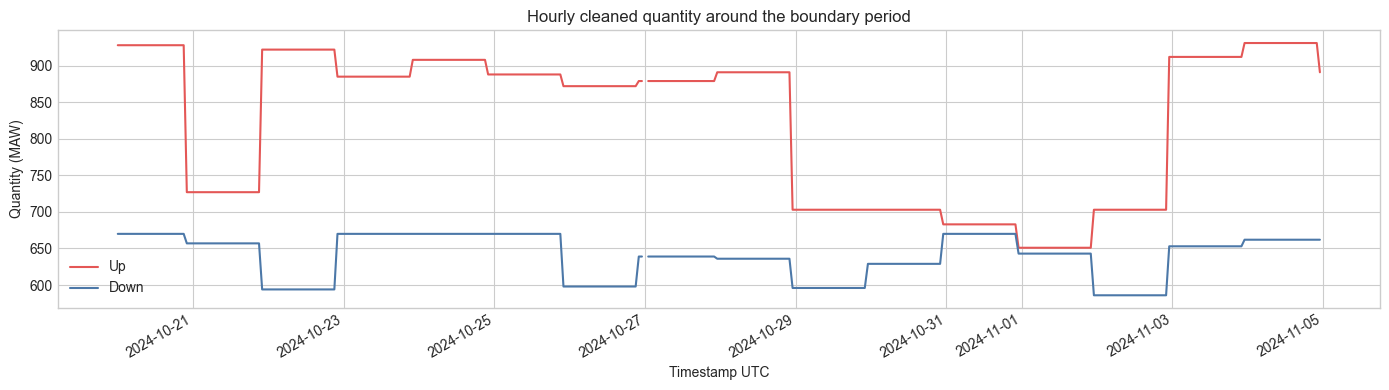

In [16]:
incomplete_hours = hourly_long.loc[~hourly_long["is_complete_hour"]].copy()
display(incomplete_hours)

sample_hourly = hourly_long[
    (hourly_long["timestamp_utc"] >= pd.Timestamp("2024-10-20 00:00:00+00:00"))
    & (hourly_long["timestamp_utc"] < pd.Timestamp("2024-11-05 00:00:00+00:00"))
]

fig, ax = plt.subplots(figsize=(14, 4))
for label, color in [("Up", "#E45756"), ("Down", "#4C78A8")]:
    subset = sample_hourly[sample_hourly["flow_direction_label"] == label]
    ax.plot(subset["timestamp_utc"], subset["quantity_maw"], label=label, color=color)
ax.set_title("Hourly cleaned quantity around the boundary period")
ax.set_ylabel("Quantity (MAW)")
ax.set_xlabel("Timestamp UTC")
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 8. Save the Cleaned Outputs

The final step writes every cleaned artifact and diagnostic table to the dataset-specific cleaned folder.


In [17]:
metadata = cleaning.write_outputs(
    output_root=REPO_ROOT / "data" / "01_cleaned",
    points_long=points_long,
    blocks_long=blocks_long,
    quarterhour_long=quarterhour_long,
    quarterhour_wide=quarterhour_wide,
    hourly_long=hourly_long,
    hourly_wide=hourly_wide,
    file_summary=file_summary_df,
    parse_errors=parse_errors_df,
    points_summary=points_summary,
    period_diagnostics=period_diagnostics,
    blocks_summary=blocks_summary,
    quarterhour_summary=quarterhour_summary,
    hourly_summary=hourly_summary,
    gap_intervals=gap_intervals,
    gap_summary=gap_summary,
    duplicates_removed=duplicates_removed,
)

display(pd.DataFrame({"artifact": list(metadata.keys()), "path_or_value": [str(v) for v in metadata.values()]}))


,artifact,path_or_value
0,dataset,12_3_e_nl_ir_a61
1,market,NL
2,market_timezone_for_reporting,Europe/Amsterdam
3,raw_input_dir,data\00_Raw\ENTSOE\12_3_E\12_3_E_NL_IR_A61
4,output_dir,data\01_cleaned\Balancing\12_3_e_nl_ir_a61
5,canonical_resolution,PT15M
6,known_at_rule,not_provided_in_raw_xml
7,notes,"['Raw XML timestamps are stored and cleaned in UTC. Local date and hour fields are Europe/Amsterdam reporting helpers.', 'The XML uses curveType A03 with sparse point positions. Each point is interpreted as the start of a block that runs until the next point or the end of the reported Period.', 'The derived quarter-hour table is expanded on a canonical [start, end) PT15M UTC grid. Uncovered intervals are left missing instead of being invented.', 'Hourly values are simple means across quarter-hours and are set to missing whenever hour coverage is incomplete.', 'The raw files do not provide allocationDecision_DateAndOrTime. createdDateTime reflects file creation/export timing and is not treated as a forecast-safe known-at timestamp.']"
8,code_labels,"{'document_type': {'A24': 'Bid_document'}, 'process_type': {'A61': 'Direct_activation_mFRR'}, 'business_type': {'A14': 'Aggregated_energy_data'}, 'curve_type': {'A01': 'Sequential_fixed_size_curve', 'A02': 'Point_curve', 'A03': 'Variable_block_curve', 'A04': 'Overlapping_breakpoint_curve', 'A05': 'Non_overlapping_breakpoint_curve'}, 'flow_direction': {'A01': 'Up', 'A02': 'Down', 'A03': 'Symmetric'}}"
9,points_long_path,C:\Users\marijnvalk\PycharmProjects\Thesis\data\01_cleaned\Balancing\12_3_e_nl_ir_a61\parsed\12_3_e_nl_ir_a61_points_long.csv


## 9. Interpretation

The diagnostics show a clear cleaning story:

- the raw XML is a sparse `curveType A03` change-point series
- sparse points compress a much denser PT15M delivery grid
- the 2024 file splits around `2024-10-27 00:30Z` and `2024-10-27 01:00Z`
- that split leaves one uncovered 30-minute gap per direction on the canonical quarter-hour grid
- the cleaning keeps that gap explicit instead of filling it silently
- the hourly layer carries the gap forward as incomplete-hour missingness
